In [1]:
# ==========================================================
# Imports
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("ggplot")

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
# ==========================================================
# Load Dataset
# ==========================================================

DATASET_PATH = Path("../data/generated/master_dataset.csv")

df = pd.read_csv(DATASET_PATH)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")

DATASET LOADED SUCCESSFULLY
Rows    : 100,000
Columns : 113


In [3]:
print("=" * 60)

print("DATASET SHAPE")

print("=" * 60)

print(df.shape)

DATASET SHAPE
(100000, 113)


In [4]:
print("=" * 60)

print("DATASET INFORMATION")

print("=" * 60)

df.info()

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 113 entries, Patient_ID to Confidence
dtypes: float64(16), int64(63), object(34)
memory usage: 86.2+ MB


In [5]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient_ID,100000,5000,7ECC53D9,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,100000.0,NaN,NaN,NaN,80.0084,11.9494,60.0,69.0,80.0,90.0,100.0
Age_Group,100000,4,90+,27180,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,100000,2,Male,50120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Height_cm,100000.0,NaN,NaN,NaN,164.584,11.759334,145.0,154.0,164.0,174.0,185.0
...,...,...,...,...,...,...,...,...,...,...,...
Risk_Level,100000,5,Low,33832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Alert_Level,66815,4,Watch,33832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Possible_Event,100000,6,Stable,71881,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recommendation,100000,5,"Increase hydration, encourage rest, and monito...",33832,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
print("=" * 60)

print("MISSING VALUE ANALYSIS")

print("=" * 60)

missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:

    print("✅ No Missing Values Found")

else:

    print(missing.sort_values(ascending=False))

MISSING VALUE ANALYSIS
Liver_Disease_Severity     95360
Cancer_Severity            92180
Asthma_Severity            90020
Parkinsons_Severity        88560
Thyroid_Severity           87800
COPD_Severity              86140
Anemia_Severity            85700
Alzheimers_Severity        79020
Depression_Severity        76620
Stroke_Severity            76080
Osteoporosis_Severity      74340
Kidney_Disease_Severity    69200
Diabetes_Severity          62500
Arthritis_Severity         50360
Heart_Disease_Severity     47520
Alert_Level                33185
Hypertension_Severity      29860
dtype: int64


In [7]:
print("=" * 60)

print("DUPLICATE ROW CHECK")

print("=" * 60)

duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

DUPLICATE ROW CHECK
Duplicate Rows : 0


In [8]:
print("=" * 60)

print("PATIENT VALIDATION")

print("=" * 60)

print("Unique Patients :", df["Patient_ID"].nunique())

print("Total Records :", len(df))

print("Average Records Per Patient :",

      round(len(df)/df["Patient_ID"].nunique(),2))

PATIENT VALIDATION
Unique Patients : 5000
Total Records : 100000
Average Records Per Patient : 20.0


In [9]:
df["Diabetes_Severity"].value_counts(dropna=False)


Diabetes_Severity
NaN         62500
Mild        20360
Moderate    11080
Severe       6060
Name: count, dtype: int64

In [10]:
df = pd.read_csv(
    DATASET_PATH,
    keep_default_na=False
)

In [11]:
df["Diabetes_Severity"].value_counts(dropna=False)

Diabetes_Severity
None        62500
Mild        20360
Moderate    11080
Severe       6060
Name: count, dtype: int64

In [12]:
print("=" * 60)

print("MISSING VALUE ANALYSIS")

print("=" * 60)

missing = df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:

    print("✅ No Missing Values Found")

else:

    print(missing.sort_values(ascending=False))

MISSING VALUE ANALYSIS
✅ No Missing Values Found


AGE DISTRIBUTION
count    100000.0000
mean         80.0084
std          11.9494
min          60.0000
25%          69.0000
50%          80.0000
75%          90.0000
max         100.0000
Name: Age, dtype: float64


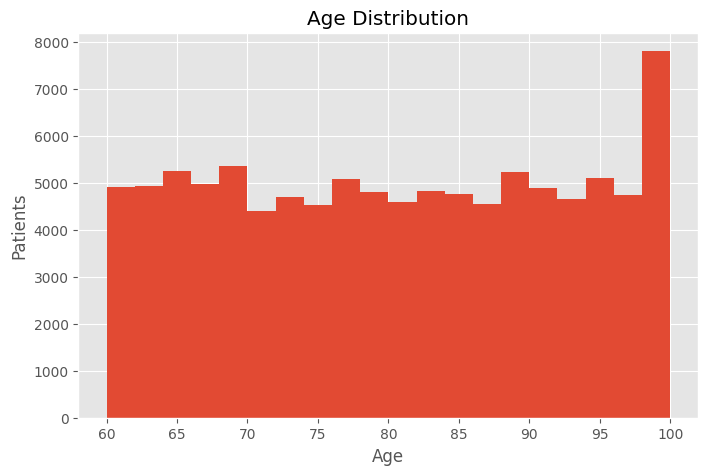

In [13]:
print("=" * 60)
print("AGE DISTRIBUTION")
print("=" * 60)

print(df["Age"].describe())

plt.figure(figsize=(8,5))
df["Age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Patients")
plt.show()

Gender
Male      50120
Female    49880
Name: count, dtype: int64


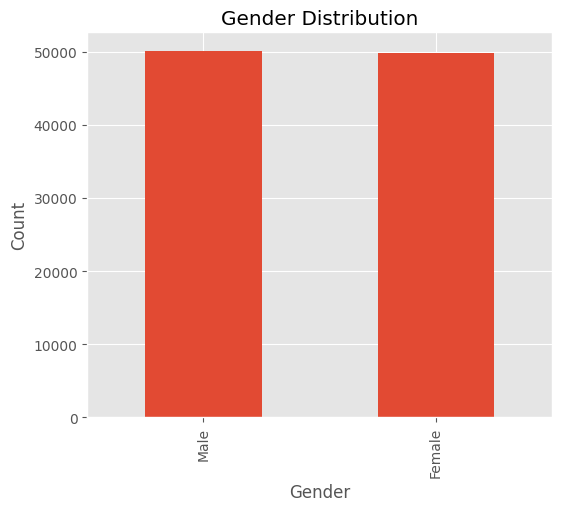

In [14]:
print(df["Gender"].value_counts())

plt.figure(figsize=(6,5))

df["Gender"].value_counts().plot(
    kind="bar"
)

plt.title("Gender Distribution")
plt.ylabel("Count")

plt.show()

count    100000.000000
mean         28.196440
std           8.706796
min          11.900000
25%          21.200000
50%          27.800000
75%          34.200000
max          52.300000
Name: BMI, dtype: float64


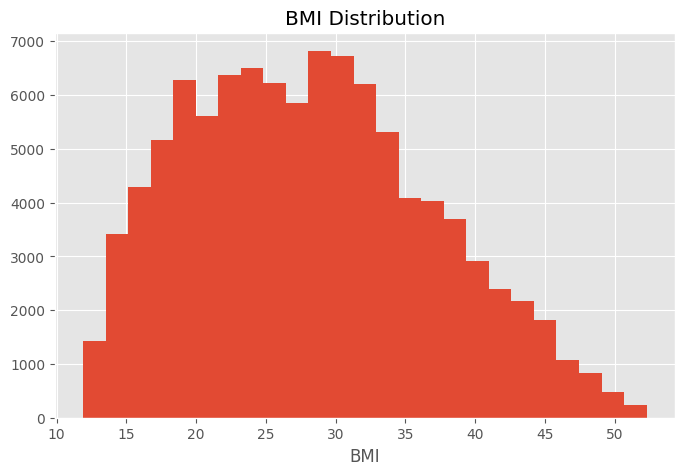

In [15]:
print(df["BMI"].describe())

plt.figure(figsize=(8,5))

df["BMI"].hist(bins=25)

plt.title("BMI Distribution")

plt.xlabel("BMI")

plt.show()

Blood_Group
O+     13480
B+     12780
AB+    12680
A-     12640
AB-    12260
O-     12220
A+     12100
B-     11840
Name: count, dtype: int64


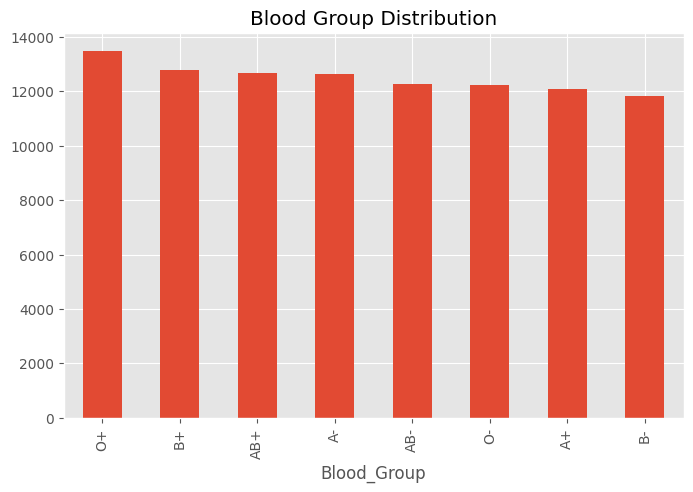

In [16]:
print(df["Blood_Group"].value_counts())

plt.figure(figsize=(8,5))

df["Blood_Group"].value_counts().plot(
    kind="bar"
)

plt.title("Blood Group Distribution")

plt.show()

DISEASE PREVALENCE
Hypertension      70140
Heart_Disease     52480
Arthritis         49640
Diabetes          37500
Kidney_Disease    30800
Osteoporosis      25660
Stroke            23920
Depression        23380
Alzheimers        20980
Anemia            14300
COPD              13860
Thyroid           12200
Parkinsons        11440
Asthma             9980
Cancer             7820
Liver_Disease      4640
dtype: int64


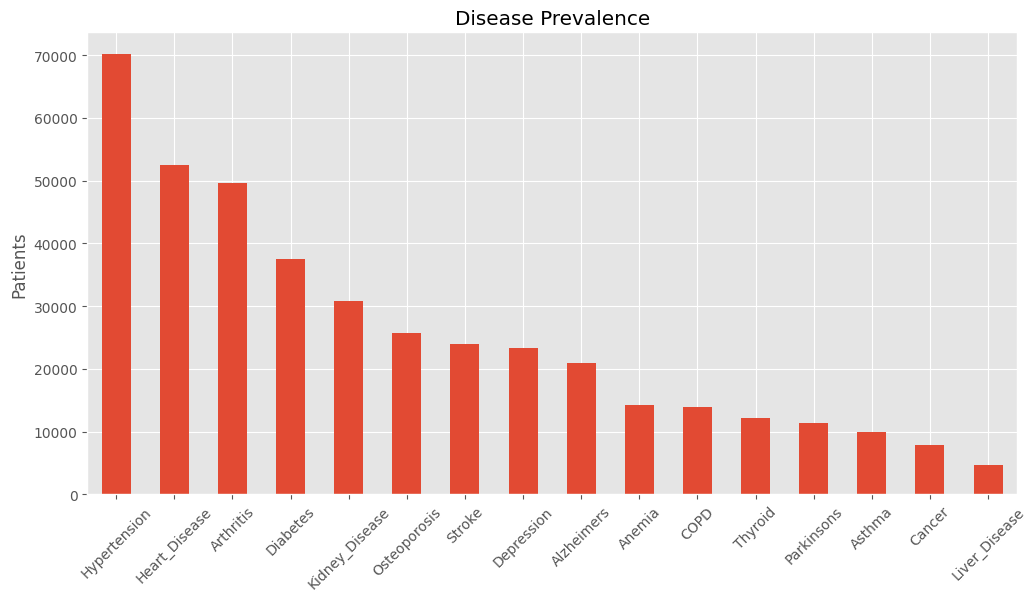

In [17]:
print("=" * 70)
print("DISEASE PREVALENCE")
print("=" * 70)

disease_columns = [

    "Diabetes",
    "Hypertension",
    "Heart_Disease",
    "Stroke",
    "Parkinsons",
    "Alzheimers",
    "Asthma",
    "COPD",
    "Kidney_Disease",
    "Liver_Disease",
    "Arthritis",
    "Thyroid",
    "Cancer",
    "Osteoporosis",
    "Depression",
    "Anemia"

]

disease_counts = df[disease_columns].sum().sort_values(ascending=False)

print(disease_counts)

plt.figure(figsize=(12,6))

disease_counts.plot(kind="bar")

plt.title("Disease Prevalence")

plt.ylabel("Patients")

plt.xticks(rotation=45)

plt.show()

In [18]:
severity_columns = [

    c for c in df.columns

    if c.endswith("_Severity")

]

print(f"Total Severity Columns : {len(severity_columns)}")

Total Severity Columns : 16


In [19]:
disease_percentage = (

    df[disease_columns].mean()*100

).round(2)

print(disease_percentage.sort_values(ascending=False))

Hypertension      70.14
Heart_Disease     52.48
Arthritis         49.64
Diabetes          37.50
Kidney_Disease    30.80
Osteoporosis      25.66
Stroke            23.92
Depression        23.38
Alzheimers        20.98
Anemia            14.30
COPD              13.86
Thyroid           12.20
Parkinsons        11.44
Asthma             9.98
Cancer             7.82
Liver_Disease      4.64
dtype: float64


In [20]:
for column in severity_columns:

    print("="*60)

    print(column)

    print("="*60)

    print(

        df[column].value_counts(dropna=False)

    )

    print()

Diabetes_Severity
Diabetes_Severity
None        62500
Mild        20360
Moderate    11080
Severe       6060
Name: count, dtype: int64

Hypertension_Severity
Hypertension_Severity
Mild        37980
None        29860
Moderate    21700
Severe      10460
Name: count, dtype: int64

Heart_Disease_Severity
Heart_Disease_Severity
None        47520
Mild        28740
Moderate    15600
Severe       8140
Name: count, dtype: int64

Stroke_Severity
Stroke_Severity
None        76080
Mild        13540
Moderate     6840
Severe       3540
Name: count, dtype: int64

COPD_Severity
COPD_Severity
None        86140
Mild         7920
Moderate     3940
Severe       2000
Name: count, dtype: int64

Asthma_Severity
Asthma_Severity
None        90020
Mild         5460
Moderate     2900
Severe       1620
Name: count, dtype: int64

Kidney_Disease_Severity
Kidney_Disease_Severity
None        69200
Mild        17240
Moderate     9100
Severe       4460
Name: count, dtype: int64

Parkinsons_Severity
Parkinsons_Severity
N

HEART RATE ANALYSIS
count    100000.000000
mean         81.649500
std          18.819628
min          45.000000
25%          69.000000
50%          79.000000
75%          93.000000
max         153.000000
Name: Heart_Rate, dtype: float64


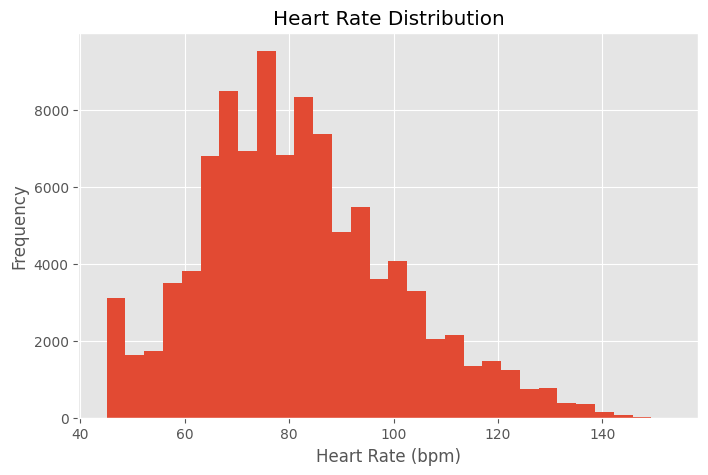

In [21]:
print("=" * 70)
print("HEART RATE ANALYSIS")
print("=" * 70)

print(df["Heart_Rate"].describe())

plt.figure(figsize=(8,5))

df["Heart_Rate"].hist(bins=30)

plt.title("Heart Rate Distribution")

plt.xlabel("Heart Rate (bpm)")

plt.ylabel("Frequency")

plt.show()

In [22]:
print("=" * 70)
print("SYSTOLIC BP")
print("=" * 70)

print(df["Systolic_BP"].describe())

print()

print("=" * 70)
print("DIASTOLIC BP")
print("=" * 70)

print(df["Diastolic_BP"].describe())

SYSTOLIC BP
count    100000.000000
mean        131.789830
std          23.787553
min          80.000000
25%         117.000000
50%         128.000000
75%         146.000000
max         220.000000
Name: Systolic_BP, dtype: float64

DIASTOLIC BP
count    100000.000000
mean         84.524310
std          17.939689
min          40.000000
25%          74.000000
50%          83.000000
75%          95.000000
max         130.000000
Name: Diastolic_BP, dtype: float64


In [23]:
print("=" * 70)
print("PULSE PRESSURE")
print("=" * 70)

print(df["Pulse_Pressure"].describe())

print()

print("Negative Pulse Pressure :",

      (df["Pulse_Pressure"] < 0).sum())

PULSE PRESSURE
count    100000.000000
mean         47.265520
std          10.639362
min          25.000000
25%          40.000000
50%          47.000000
75%          54.000000
max         101.000000
Name: Pulse_Pressure, dtype: float64

Negative Pulse Pressure : 0


count    100000.000000
mean         93.991760
std           5.941613
min          75.000000
25%          91.000000
50%          96.000000
75%          98.000000
max         100.000000
Name: SpO2, dtype: float64


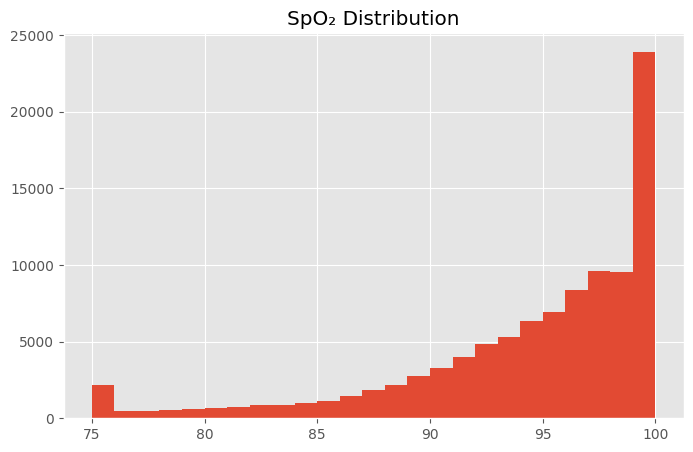

In [24]:
print(df["SpO2"].describe())

plt.figure(figsize=(8,5))

df["SpO2"].hist(bins=25)

plt.title("SpO₂ Distribution")

plt.show()

count    100000.000000
mean         36.894677
std           0.729662
min          35.500000
25%          36.500000
50%          36.800000
75%          37.800000
max          41.000000
Name: Temperature, dtype: float64


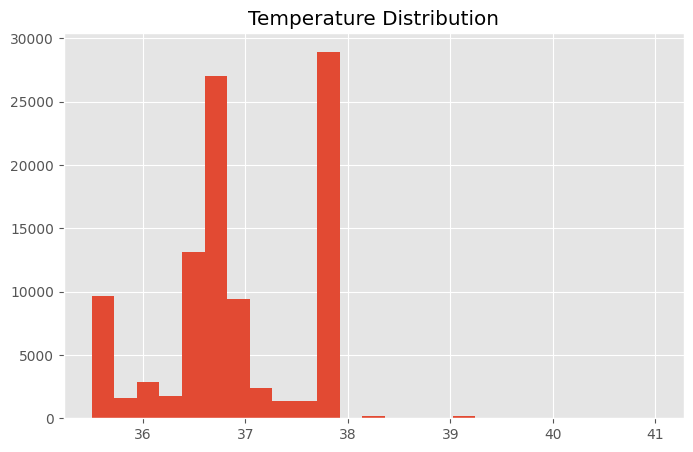

In [25]:
print(df["Temperature"].describe())

plt.figure(figsize=(8,5))

df["Temperature"].hist(bins=25)

plt.title("Temperature Distribution")

plt.show()

count    100000.000000
mean         21.042660
std           8.789927
min           8.000000
25%          15.000000
50%          19.000000
75%          26.000000
max          40.000000
Name: Respiratory_Rate, dtype: float64


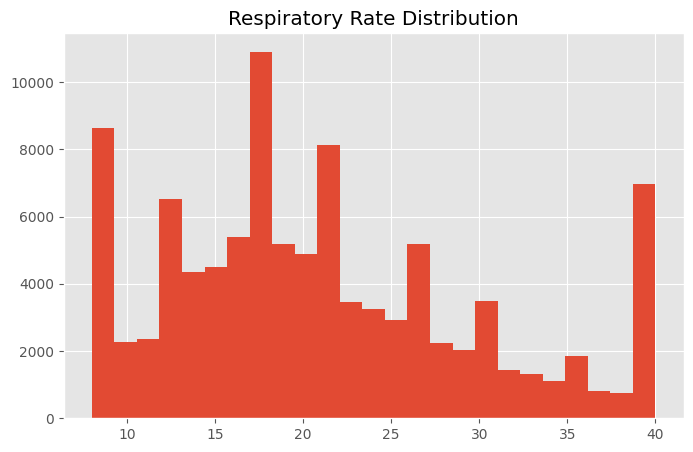

In [26]:
print(df["Respiratory_Rate"].describe())

plt.figure(figsize=(8,5))

df["Respiratory_Rate"].hist(bins=25)

plt.title("Respiratory Rate Distribution")

plt.show()

count    100000.000000
mean         32.941680
std          19.615245
min           0.000000
25%          16.800000
50%          28.200000
75%          48.300000
max          82.000000
Name: Clinical_Score, dtype: float64


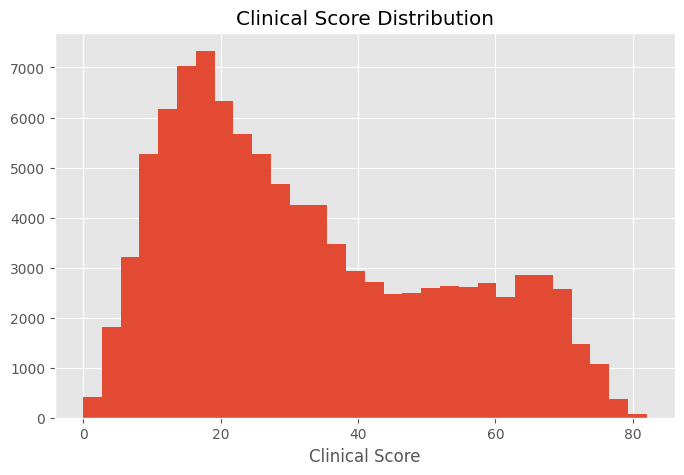

In [27]:
print(df["Clinical_Score"].describe())

plt.figure(figsize=(8,5))

df["Clinical_Score"].hist(bins=30)

plt.title("Clinical Score Distribution")

plt.xlabel("Clinical Score")

plt.show()

In [28]:
print(df["Risk_Level"].value_counts())

print()

print(df["Alert_Level"].value_counts())

Risk_Level
Low         33832
Stable      33185
Moderate    18976
High        13959
Critical       48
Name: count, dtype: int64

Alert_Level
Watch               33832
None                33185
Notify Caregiver    18976
Urgent              13959
Emergency              48
Name: count, dtype: int64


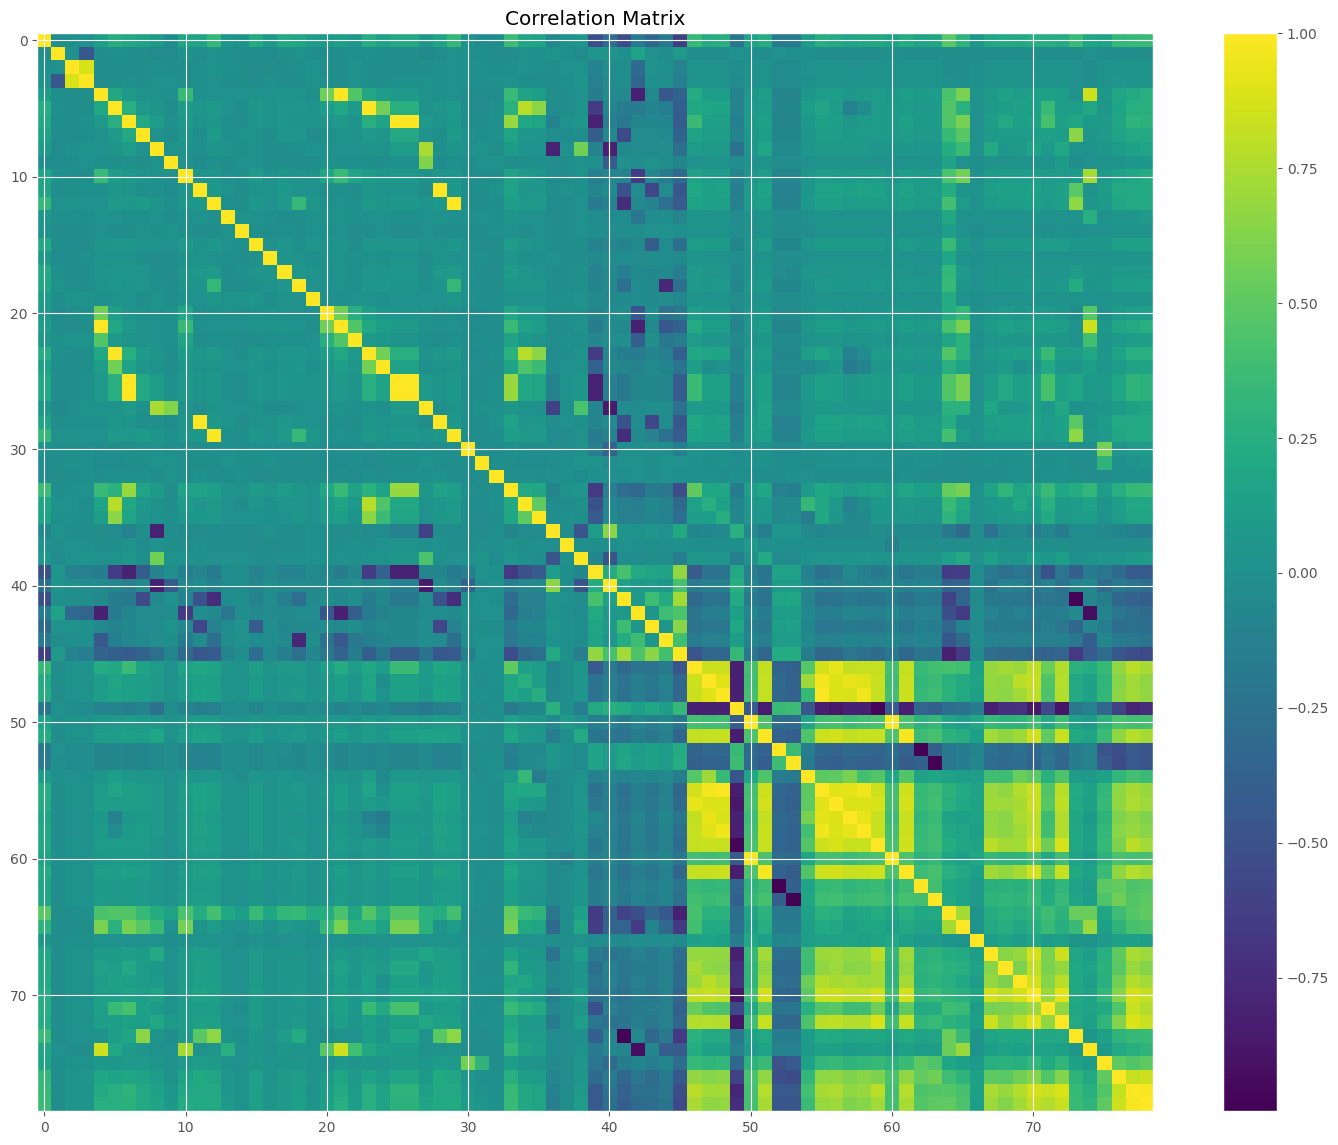

In [29]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include="number")

corr = numeric_df.corr()

plt.figure(figsize=(18,14))

plt.imshow(corr, aspect="auto")

plt.colorbar()

plt.title("Correlation Matrix")

plt.show()